In [1]:
# simu_modules.ipynb - compare simu-data count matrices generated by different modules.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys

In [4]:
#module = 'A'
#module = 'B'
#module = 'U'
module = 'X'    # A+B+U

In [5]:
in_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/internal_consistency/simu_modules_cs-rs/pp"
out_stat_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/internal_consistency/simu_modules_cs-rs/%s/stats" % module
out_fig_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/internal_consistency/simu_modules_cs-rs/%s/figures" % module

In [6]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/internal_consistency/simu_modules_cs-rs/scripts"
sys.path.append(utils_dir)
from ubase import *
from urdr import *

In [7]:
os.makedirs(out_stat_dir, exist_ok = True)
os.makedirs(out_fig_dir, exist_ok = True)

In [8]:
cw_prefix = 'cw-'
gw_prefix = 'gw-'

dpi = 300

In [9]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [10]:
tool_labels = ['cs_N', 'rs_N', 'cs_T', 'rs_T']
tool_palette = {
    'cs_N': '#56B4E9',
    'rs_N': green,
    'cs_T': '#F0E442',
    'rs_T': blue
}

# Load Data

In [11]:
cs_normal_fn = os.path.join(in_dir, "cs_normal.h5ad")
rs_normal_fn = os.path.join(in_dir, "rs_normal.h5ad")
cs_tumor_fn = os.path.join(in_dir, "cs_tumor.h5ad")
rs_tumor_fn = os.path.join(in_dir, "rs_tumor.h5ad")

In [12]:
cs_normal = ad.read_h5ad(cs_normal_fn)
print(cs_normal)

rs_normal = ad.read_h5ad(rs_normal_fn)
print(rs_normal)

cs_tumor = ad.read_h5ad(cs_tumor_fn)
print(cs_tumor)

rs_tumor = ad.read_h5ad(rs_tumor_fn)
print(rs_tumor)

AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell_type', 'cell'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell_type', 'cell'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 32295
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'


In [13]:
if module != 'X':
    for adata in [cs_normal, rs_normal, cs_tumor, rs_tumor]:
        adata.X = adata.layers[module]

# Cell-wise Metrics

In [14]:
mv = get_cw_metrics_group(
    X_lst = [cs_normal.X, rs_normal.X, cs_tumor.X, rs_tumor.X],
    X_names = tool_labels,
    id_lst = [cs_normal.obs['cell'].to_numpy(), rs_normal.obs['cell'].to_numpy(),
              cs_tumor.obs['cell'].to_numpy(), rs_tumor.obs['cell'].to_numpy()],
    metrics = ["lib_size", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,lib_size,zero_prop,group,cell
0,5927,0.939279,cs_N,AAACCTGGTCAAAGAT-1
1,14259,0.892181,cs_N,AAACCTGGTCCCGACA-1
2,10398,0.913206,cs_N,AAACGGGAGAGCTTCT-1
3,4705,0.947298,cs_N,AAACGGGGTATAGGTA-1
4,7360,0.928782,cs_N,AAAGATGGTCTGGAGA-1
...,...,...,...,...
2395,15514,0.884131,rs_T,TTTCCTCTCCATGAAC-1
2396,10049,0.909305,rs_T,TTTGCGCTCTCTAAGG-1
2397,7661,0.922248,rs_T,TTTGGTTCAACTTGAC-1
2398,6059,0.935346,rs_T,TTTGGTTCATTGTGCA-1


In [15]:
tmp = mv[["group", "cell", "lib_size", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_stat_dir, cw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

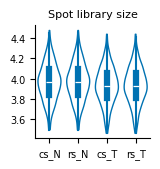

In [16]:
fig = plt.figure(figsize = (1.7, 1.8))

x = mv['group']
y = mv['lib_size']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = 'box',
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 7
)
if module in ['A', 'B']:
    ax.set_yticks([1.8, 2.0, 2.2, 2.4, 2.6, 2.8])
elif module == 'U':
    ax.set_yticks([3.4, 3.6, 3.8, 4.0, 4.2, 4.4])
    ax.set_ylim(3.375, 4.5)
else:
    ax.set_yticks([3.6, 3.8, 4.0, 4.2, 4.4])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Spot library size", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, cw_prefix + "libsize.png")
fig.savefig(fn, dpi = 300)

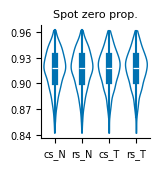

In [17]:
fig = plt.figure(figsize = (1.7, 1.8))

x = mv['group']
y = mv['zero_prop']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = 'box',
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 7
)
if module in ['A']:
    ax.set_yticks([0.994, 0.995, 0.996, 0.997, 0.998, 0.999])
elif module == 'B':
    ax.set_yticks([0.994, 0.995, 0.996, 0.997, 0.998, 0.999])
elif module == 'U':
    ax.set_yticks([0.84, 0.87, 0.9, 0.93, 0.96])
    ax.set_ylim(0.835, 0.97)
else:
    ax.set_yticks([0.84, 0.87, 0.9, 0.93, 0.96])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Spot zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, cw_prefix + "zero_prop.png")
fig.savefig(fn, dpi = 300)

# Gene-wise Metrics

In [18]:
mv = get_gw_metrics_group(
    X_lst = [cs_normal.X, rs_normal.X, cs_tumor.X, rs_tumor.X],
    X_names = tool_labels,
    id_lst = [cs_normal.var['feature'].to_numpy(), rs_normal.var['feature'].to_numpy(),
              cs_tumor.var['feature'].to_numpy(), rs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean,var,cv,zero_prop,group,feature
0,0.000000,0.000000,0.000000,1.000000,cs_N,MIR1302-2HG
1,0.000000,0.000000,0.000000,1.000000,cs_N,FAM138A
2,0.000000,0.000000,0.000000,1.000000,cs_N,OR4F5
3,0.000000,0.000000,0.000000,1.000000,cs_N,AL627309.1
4,0.000000,0.000000,0.000000,1.000000,cs_N,AL627309.3
...,...,...,...,...,...,...
129175,0.083333,0.079722,3.388215,0.918333,rs_T,ARRDC1-AS1
129176,0.235000,0.269775,2.210207,0.803333,rs_T,EHMT1
129177,0.000000,0.000000,0.000000,1.000000,rs_T,AL772363.1
129178,0.000000,0.000000,0.000000,1.000000,rs_T,CACNA1B


In [19]:
tmp = mv[["group", "feature", "mean", "var", "cv", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

## Single Metric

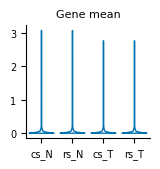

In [20]:
fig = plt.figure(figsize = (1.7, 1.8))

x = mv['group']
y = mv['mean']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 7
)
if module in ['A', 'B']:
    ax.set_yticks([0, 0.5, 1.0, 1.5])
else:
    ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene mean", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "mean.png")
fig.savefig(fn, dpi = 300)

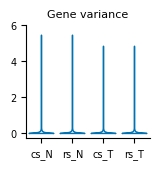

In [21]:
fig = plt.figure(figsize = (1.7, 1.8))

x = mv['group']
y = mv['var']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 7
)
if module in ['A', 'B']:
    ax.set_yticks([0, 0.5, 1.0, 1.5, 2, 2.5])
elif module == 'U':
    ax.set_yticks([0, 2, 4, 6])
else:
    ax.set_yticks([0, 2, 4, 6])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene variance", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "variance.png")
fig.savefig(fn, dpi = 300)

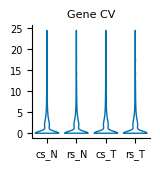

In [22]:
fig = plt.figure(figsize = (1.7, 1.8))

x = mv['group']
y = mv['cv']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 7
)
ax.set_yticks([0, 5, 10, 15, 20, 25])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene CV", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "cv.png")
fig.savefig(fn, dpi = 300)

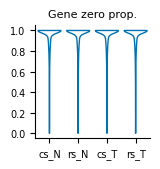

In [23]:
fig = plt.figure(figsize = (1.7, 1.8))

x = mv['group']
y = mv['zero_prop']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 7
)
if module in ['A', 'B']:
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
else:
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "zero_prop.png")
fig.savefig(fn, dpi = 300)

### Percentage of genes within specific ranges of zero proportions

In [24]:
st_zeroprop = stat_stack_zeroprop(
    data = mv, 
    metric = "zero_prop",
    group = "group", 
    cutoffs = [.9, .99, 1.01], 
    labels = ["[0, 0.9)", "[0.9, 0.99)", "[0.99, 1]"]
)
print(st_zeroprop)


tmp = st_zeroprop[["group", "cutoff", "label", "percent"]]
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "perc-of-genes-on-zero_prop.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

   group  level_1  cutoff        label    percent
0   cs_N        0    0.90     [0, 0.9)  22.381174
1   cs_N        1    0.99  [0.9, 0.99)  17.513547
2   cs_N        2    1.01    [0.99, 1]  60.105279
3   rs_N        0    0.90     [0, 0.9)  22.381174
4   rs_N        1    0.99  [0.9, 0.99)  17.513547
5   rs_N        2    1.01    [0.99, 1]  60.105279
6   cs_T        0    0.90     [0, 0.9)  22.080817
7   cs_T        1    0.99  [0.9, 0.99)  17.733395
8   cs_T        2    1.01    [0.99, 1]  60.185787
9   rs_T        0    0.90     [0, 0.9)  22.080817
10  rs_T        1    0.99  [0.9, 0.99)  17.733395
11  rs_T        2    1.01    [0.99, 1]  60.185787


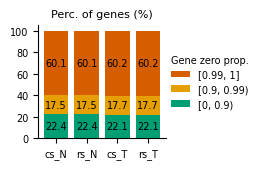

In [25]:
data = st_zeroprop
x, y, hue = 'group', 'percent', 'label'
min_v = 10
font_size = 7
colors = [green, orange, red]

# prepare data.
df = long2wide(data, index = x, columns = hue, values = y)
df[x] = df.index
hue_groups = data[hue].unique()
cumsum = np.array([0.0] * df.shape[0])

# plot.
fig = plt.figure(figsize = (2.7, 1.8))

for i, h in enumerate(hue_groups):
    if i == 0:
        plt.bar(df[x], df[h], label = h, color = colors[i])
    else:
        ax = plt.gca()
        ax.bar(df[x], df[h], label = h, bottom = cumsum, color = colors[i])
    cumsum += df[h]
        
for c in ax.containers:
    labels = [str(round(v.get_height(), 1))    \
                if v.get_height() > min_v else '' for v in c]
    ax.bar_label(c, label_type = 'center', labels = labels, 
                    fontsize = font_size, color = 'black')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    fontsize = 7
)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_ylabel("")
ax.set_xlabel("")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles = handles[::-1],
    labels = labels[::-1],
    title = "Gene zero prop.",
    loc = 'center left',
    bbox_to_anchor = [0.97, 0.5],
    title_fontsize = font_size,
    fontsize = font_size,
    alignment = 'left',
    frameon = False
)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Perc. of genes (%)", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "perc-of-genes-on-zero_prop.png")
fig.savefig(fn, dpi = 300)

## Pair of Metrics

In [26]:
st_smooth = stat_smooth(
    x = "mean",
    y = "zero_prop",
    data = mv, 
    k = 100,
    group = "group",
    log_scale = (True, False),
    ncores = 20
)
print(st_smooth)

st_smooth.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "zero_prop-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

processing group 'cs_N' ...
processing group 'rs_N' ...
processing group 'cs_T' ...
processing group 'rs_T' ...
       group      mean     zero_prop
0       cs_N  0.000000  1.000000e+00
1       cs_N  0.000000  1.000000e+00
2       cs_N  0.000000  1.000000e+00
3       cs_N  0.000000  1.000000e+00
4       cs_N  0.000000  1.000000e+00
...      ...       ...           ...
129175  rs_T  2.281957  1.252438e-05
129176  rs_T  2.306457  1.059773e-05
129177  rs_T  2.342393  8.233988e-06
129178  rs_T  2.386169  5.986649e-06
129179  rs_T  2.771613  2.316647e-07

[129180 rows x 3 columns]


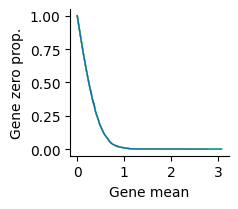

In [27]:
fig = plt.figure(figsize = (2.4, 2.2))
ax = sns.lineplot(
    st_smooth, x = "mean", y = "zero_prop", hue = 'group', 
    legend = False,
    linewidth = 1,
    palette = tool_palette
)
if module in ['A', 'B']:
    ax.set_xticks([0, 0.5, 1.0, 1.5])
else:
    ax.set_xticks([0, 1, 2, 3])
ax.set_xlabel(r"Gene mean")
ax.set_ylabel("Gene zero prop.")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "zero_prop-vs-mean.png")
fig.savefig(fn, dpi = 300)

In [28]:
st_smooth = stat_smooth(
    x = "mean",
    y = "var",
    data = mv,
    k = 100,
    group = "group",
    log_scale = (True, True),
    ncores = 20
)
print(st_smooth)

st_smooth.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "var-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

processing group 'cs_N' ...
processing group 'rs_N' ...
processing group 'cs_T' ...
processing group 'rs_T' ...
       group      mean       var
0       cs_N  0.000000  0.000000
1       cs_N  0.000000  0.000000
2       cs_N  0.000000  0.000000
3       cs_N  0.000000  0.000000
4       cs_N  0.000000  0.000000
...      ...       ...       ...
129175  rs_T  2.281957  3.328956
129176  rs_T  2.306457  3.372485
129177  rs_T  2.342393  3.434158
129178  rs_T  2.386169  3.505700
129179  rs_T  2.771613  4.014784

[129180 rows x 3 columns]


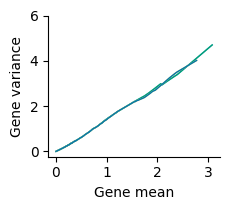

In [29]:
fig = plt.figure(figsize = (2.4, 2.2))
ax = sns.lineplot(
    st_smooth, x = "mean", y = "var", hue = 'group', 
    legend = False,
    linewidth = 1,
    palette = tool_palette
)
if module in ['A', 'B']:
    ax.set_xticks([0, 0.5, 1.0, 1.5])
else:
    ax.set_xticks([0, 1, 2, 3])

if module in ['A', 'B']:
    ax.set_yticks([0, 0.5, 1.0, 1.5, 2, 2.5])
elif module == 'U':
    ax.set_yticks([0, 1, 2, 3, 4, 5])
else:
    ax.set_yticks([0, 2, 4, 6])
ax.set_xlabel(r"Gene mean")
ax.set_ylabel(r"Gene variance")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "var-vs-mean.png")
fig.savefig(fn, dpi = 300)

In [30]:
mv2 = mv[~((mv["mean"] <= 0) & (mv["cv"] <= 0))].copy()

st_smooth = stat_smooth(
    x = "mean",
    y = "cv",
    data = mv2, 
    k = 100,
    group = "group",
    log_scale = (True, False),
    ncores = 20
)
print(st_smooth)

st_smooth.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "cv-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

processing group 'cs_N' ...
processing group 'rs_N' ...
processing group 'cs_T' ...
processing group 'rs_T' ...
      group      mean         cv
0      cs_N  0.000723  24.474475
1      cs_N  0.000723  24.474475
2      cs_N  0.000723  24.474475
3      cs_N  0.000723  24.474475
4      cs_N  0.000723  24.474475
...     ...       ...        ...
58427  rs_T  2.281957   0.462985
58428  rs_T  2.306457   0.462073
58429  rs_T  2.342393   0.460867
58430  rs_T  2.386169   0.459600
58431  rs_T  2.771613   0.454278

[58432 rows x 3 columns]


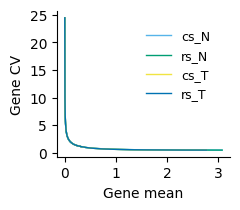

In [31]:
fig = plt.figure(figsize = (2.5, 2.2))
ax = sns.lineplot(
    st_smooth, x = "mean", y = "cv", hue = 'group',
    linewidth = 1,
    palette = tool_palette
)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles = handles, labels = tool_labels)
sns.move_legend(
    ax, "upper left", title = None, frameon = False,
    bbox_to_anchor = (0.45, 0.95), fontsize = 9
)
if module in ['A', 'B']:
    ax.set_xticks([0, 0.5, 1.0, 1.5])
else:
    ax.set_xticks([0, 1, 2, 3])

ax.set_yticks([0, 5, 10, 15, 20, 25])
ax.set_xlabel(r"Gene mean")
ax.set_ylabel("Gene CV")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "cv-vs-mean.png")
fig.savefig(fn, dpi = 300)

## Linear Regression

In [32]:
pairs = [
    ("rs_N", "cs_N"),
    ("rs_T", "cs_T")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [33]:
st_lr = stat_LR(
    data = mv,
    metric = "mean", group = "group", gvars = selected_gvars, 
    log_scale = True
)
print(st_lr)

tmp = st_lr.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "mean-lr-stat.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

      x     y    a             b   r2  p_value
0  cs_N  rs_N  1.0  1.615461e-17  1.0      0.0
1  cs_T  rs_T  1.0  2.802663e-17  1.0      0.0


In [34]:
df_mean = long2wide(mv, columns = 'group', values = 'mean', index = 'feature')
print(df_mean)

tmp = df_mean.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "mean-lr.tsv"), 
    header = True, 
    index = True, 
    sep = "\t"
)

group            cs_N      rs_N      cs_T      rs_T
feature                                            
MIR1302-2HG  0.000000  0.000000  0.000000  0.000000
FAM138A      0.000000  0.000000  0.000000  0.000000
OR4F5        0.000000  0.000000  0.000000  0.000000
AL627309.1   0.000000  0.000000  0.000000  0.000000
AL627309.3   0.000000  0.000000  0.000000  0.000000
...               ...       ...       ...       ...
ARRDC1-AS1   0.070000  0.070000  0.083333  0.083333
EHMT1        0.208333  0.208333  0.235000  0.235000
AL772363.1   0.000000  0.000000  0.000000  0.000000
CACNA1B      0.000000  0.000000  0.000000  0.000000
AL954642.1   0.000000  0.000000  0.000000  0.000000

[32295 rows x 4 columns]


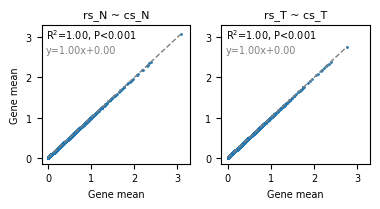

In [35]:
ncols = 2
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (3.9, 2.2))

pos_r = (.03, .9)
pos_fit = (.03, .8)
fit_kws = dict()
fontsize = 7

columns = np.asarray(df_mean.columns)
df = df_mean[columns].copy()
df = df.map(lambda x: np.log10(x + 1))

gvars = st_lr[['x', 'y']].copy()
x_min, x_max = None, None
cols = np.union1d(gvars['x'], gvars['y'])
for c in cols:
    if x_min is None:
        x_min = df[c].min()
    elif df[c].min() < x_min:
        x_min = df[c].min()
    if x_max is None:
        x_max = df[c].max()
    elif df[c].max() > x_max:
        x_max = df[c].max()
xlims = (x_min, x_max)
    
k = 0
for i in range(gvars.shape[0]):
    ax = axs.flat[k]
    cx = gvars['x'].loc[i]
    cy = gvars['y'].loc[i]
    d = st_lr.loc[(st_lr['x'] == cx) & (st_lr['y'] == cy)]
    assert d.shape[0] == 1
    a = d['a'].iloc[0]
    b = d['b'].iloc[0]
    r2 = d['r2'].iloc[0]
    p_value = d['p_value'].iloc[0]

    x, y = df[cx], df[cy]
    ax.plot(x, y, marker = '.', markersize = 2, linestyle = 'none')
    x_vals = np.linspace(max(ax.get_xlim()[0], np.min(x)), 
                        min(ax.get_xlim()[1], np.max(x)), 100)

    color_fit = fit_kws.get('color', 'gray')
    ax.plot(
        x_vals, a*x_vals+b, 
        linestyle = fit_kws.get('linestyle', '--'), 
        color = color_fit, 
        linewidth = fit_kws.get('linewidth', 1.0)
    )
    equation_str = format_equation(a, b)
    ax.annotate(equation_str, xy = pos_fit, xycoords = ax.transAxes,
                color = color_fit, fontsize = fontsize)
    pv_str = format_pvalue(p_value) 
    ax.annotate(r"R$^2$=%.2f, %s" % (r2, pv_str), xy = pos_r, 
                xycoords = ax.transAxes, fontsize = fontsize)

    ax.set_title(None)
    ax.set_xlabel("Gene mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene mean", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize + 1)
    if module in ['A', 'B']:
        ax.set_xticks([0, 0.5, 1.0, 1.5])
    else:
        ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    if module in ['A', 'B']:
        ax.set_yticks([0, 0.5, 1.0, 1.5])
    else:
        ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    if module in ['A', 'B']:
        ax.set_xlim(-0.15, 1.7)
        ax.set_ylim(-0.15, 1.7)
    else:
        ax.set_xlim(-0.15, 3.3)
        ax.set_ylim(-0.15, 3.3)
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "mean-lr.png")
fig.savefig(fn, dpi = 300)

### Log2FC vs. Mean

In [36]:
st_log2fc = stat_log2fc(
    data = mv,
    metric = "mean", group = "group", gvars = selected_gvars
)
print(st_log2fc)


tmp = st_log2fc.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "log2fc-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

          x     y    mean_x    mean_y  log2FC
0      cs_N  rs_N  0.000000  0.000000     0.0
1      cs_N  rs_N  0.000000  0.000000     0.0
2      cs_N  rs_N  0.000000  0.000000     0.0
3      cs_N  rs_N  0.000000  0.000000     0.0
4      cs_N  rs_N  0.000000  0.000000     0.0
...     ...   ...       ...       ...     ...
64585  cs_T  rs_T  0.083333  0.083333     0.0
64586  cs_T  rs_T  0.235000  0.235000     0.0
64587  cs_T  rs_T  0.000000  0.000000     0.0
64588  cs_T  rs_T  0.000000  0.000000     0.0
64589  cs_T  rs_T  0.000000  0.000000     0.0

[64590 rows x 5 columns]


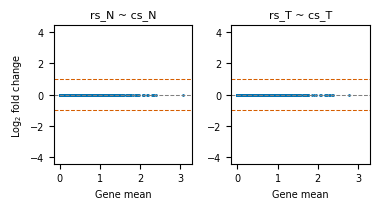

In [37]:
ncols = 2
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (3.9, 2.2))

cut = (-4, 4)
cut_markers = ('v', '^')
fontsize = 7

gvars = selected_gvars.copy()
k = 0
for i in range(gvars.shape[0]):
    ax = axs[k]
    cx = gvars['x'].iloc[i]
    cy = gvars['y'].iloc[i]
    df = st_log2fc.loc[(st_log2fc['x'] == cx) & (st_log2fc['y'] == cy)].copy()

    vx = df['mean_x'].to_numpy()
    vy = df['log2FC'].to_numpy()
    vx = np.log10(vx + 1)

    low, high = cut
    x1 = vx[vy > high]
    y1 = np.repeat(high, len(x1))
    x2 = vx[np.logical_and(vy >= low, vy <= high)]
    y2 = vy[np.logical_and(vy >= low, vy <= high)]
    x3 = vx[vy < low]
    y3 = np.repeat(low, len(x3))
    
    ax.plot(x1, y1, marker = cut_markers[1], markersize = 2, 
            linestyle = 'none', color = def_color)
    ax.plot(x2, y2, marker = '.', markersize = 2, 
            linestyle = 'none', color = def_color)
    ax.plot(x3, y3, marker = cut_markers[0], markersize = 2, 
            linestyle = 'none', color = def_color)

    fc_kws = dict()
    ax.axhline(
        y = fc_kws.get('y_up', 1),
        linestyle = fc_kws.get('linestyle', '--'),
        linewidth = fc_kws.get('linewidth', 0.75),
        color = fc_kws.get('color', red)
    )
    ax.axhline(
        y = fc_kws.get('y_low', -1),
        linestyle = fc_kws.get('linestyle', '--'),
        linewidth = fc_kws.get('linewidth', 0.75),
        color = fc_kws.get('color', red)
    )

    ref_kws = dict()
    ax.axhline(
        y = ref_kws.get('y', 0), 
        linestyle = ref_kws.get('linestyle', '--'), 
        linewidth = ref_kws.get('linewidth', 0.75),
        color = ref_kws.get('color', 'gray')
    )
    if module in ['A', 'B']:
        ax.set_xticks([0, 0.5, 1.0, 1.5])
    else:
        ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_ylim(-4.4, 4.4)
    ax.set_yticks([-4, -2, 0, 2, 4])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    ax.set_xlabel("Gene mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel(r"Log$_2$ fold change", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize + 1)
    if module in ['A', 'B']:
        ax.set_xlim(-0.05, 1.7)
    else:
        ax.set_xlim(-0.15, 3.3)
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "log2fc-vs-mean.png")
fig.savefig(fn, dpi = 300)

In [38]:
np.log10(1 + st_log2fc['mean_x'].max()), np.log10(1 + st_log2fc['mean_y'].max())

(3.0789616305409533, 3.0789616305409533)